In [ ]:
# Setup and data pipeline

import os
import kagglehub
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# Download latest version of AffectNet-HQ
print("Downloading AffectNet-HQ...")
DATASET_PATH = kagglehub.dataset_download("viktormodroczky/facial-affect-dataset")

# Path configuration based on dataset structure
SUBFOLDER = "data_balanced_1x"
TRAIN_DIR = os.path.join(DATASET_PATH, SUBFOLDER, "train")
VAL_DIR = os.path.join(DATASET_PATH, SUBFOLDER, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 128

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode='categorical', image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Detected Classes: {class_names}")

# Augmentation Layer (Prevents overfitting)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Using Colab cache for faster access to the 'facial-affect-dataset' dataset.
Found 32808 files belonging to 8 classes.
Found 8200 files belonging to 8 classes.
Detected Classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# Dual-Branch Attention Architecture

def spatial_attention_block(input_tensor):

    # Visual Squeeze-and-Excitation Block. Learns to prioritise key facial features (eyes, mouth) over background noise.
    channels = input_tensor.shape[-1]
    # Squeeze: Global average pooling
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    # Excitation: Learn channel-wise weights
    recalibrate = layers.Dense(channels // 8, activation='relu')(avg_pool)
    recalibrate = layers.Dense(channels, activation='sigmoid')(recalibrate)
    recalibrate = layers.Reshape((1, 1, channels))(recalibrate)
    return layers.Multiply()([input_tensor, recalibrate])

def build_attention_fer_model():
    inputs = layers.Input(shape=(224, 224, 3))

    # Branch 1: Deep Feature Extraction (MobileNetV2)
    x1_in = layers.Rescaling(1./127.5, offset=-1)(inputs)
    base_v2 = applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    feat_v2 = base_v2(x1_in)

    # Apply Attention to visual features
    attended_v2 = spatial_attention_block(feat_v2)
    gap_v2 = layers.GlobalAveragePooling2D()(attended_v2)

    # Branch 2: High-Level Semantics (MobileNetV3Small)
    base_v3 = applications.MobileNetV3Small(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    feat_v3 = base_v3(inputs)
    gap_v3 = layers.GlobalAveragePooling2D()(feat_v3)

    # Late Fusion (Decision Level)
    combined = layers.Concatenate()([gap_v2, gap_v3])

    x = layers.BatchNormalization()(combined)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Use 'x' here, as that is what the Dropout layer returned
    outputs = layers.Dense(len(class_names), activation='softmax', dtype='float32')(x)

    return models.Model(inputs, outputs), base_v2, base_v3

model, base_v2, base_v3 = build_attention_fer_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ rescaling_2[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 160)       │    204,960 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1280)      │    206,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ dense_5[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Small    │ (None, 7, 7, 576) │    939,120 │ input_layer_4[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_10[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 576)       │          0 │ MobileNetV3Small… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1856)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1856)      │      7,424 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │    950,784 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │      4,104 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,570,456 (17.43 MB)

 Trainable params: 4,520,520 (17.24 MB)

 Non-trainable params: 49,936 (195.06 KB)

In [ ]:
# Two-Phase fine-tunning

# Phase 1: Warm-up (Freeze base models)
print("--- Phase 1: Warming up Classification Head ---")
base_v2.trainable = False
base_v3.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

print("--- Phase 2: Full Fine-Tuning with Attention ---")

# 1. Checkpoint path (Make sure this matches your Drive mount if used)
CHECKPOINT_FILE = "affectnet_hq_best.keras"

# 2. Unfreeze the base models
base_v2.trainable = True
base_v3.trainable = True

# 3. IMPORTANT: Freeze BN layers to preserve ImageNet statistics
# This is a deep learning best practice to avoid losing accuracy
for layer in base_v2.layers + base_v3.layers:
    if "BatchNormalization" in layer.__class__.__name__:
        layer.trainable = False

# 4. Re-compile with a very low learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Callbacks to save the best version to disk
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(CHECKPOINT_FILE, save_best_only=True, monitor='val_accuracy', verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
]

# 6. Begin final training
model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

--- Phase 1: Warming up Classification Head ---
Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 531s 2s/step - accuracy: 0.3585 - loss: 1.8667 - val_accuracy: 0.4343 - val_loss: 1.4669
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.4404 - loss: 1.4526 - val_accuracy: 0.4532 - val_loss: 1.4348
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.4685 - loss: 1.3724 - val_accuracy: 0.4516 - val_loss: 1.4105
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.4853 - loss: 1.3258 - val_accuracy: 0.4550 - val_loss: 1.4206
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.5026 - loss: 1.2941 - val_accuracy: 0.4572 - val_loss: 1.4088
--- Phase 2: Full Fine-Tuning with Attention ---
Epoch 1/25
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5386 - loss: 1.2144
Epoch 1: val_accuracy improved from None to 0.50732, saving model to affectnet_hq_best.keras

Epoch 1: finished saving model to affectnet_hq_best.keras
257/257 ━━━━━━━━━━━━━━━━━━

In [ ]:
# TFLite optimisation for Raspberry Pi

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("affectnet_hq_attention.tflite", "wb") as f:
    f.write(tflite_model)

print("Edge-Optimized Attention Model Exported.")

Saved artifact at '/tmp/tmp_vk6o3lk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_349')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  136557548582096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548584784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548584208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548582672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548581136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548584016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557546079440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557546079632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548584592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136557548583824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1365575460

Running inference on TEST set...
Found 8200 files belonging to 8 classes.
65/65 ━━━━━━━━━━━━━━━━━━━━ 27s 275ms/step


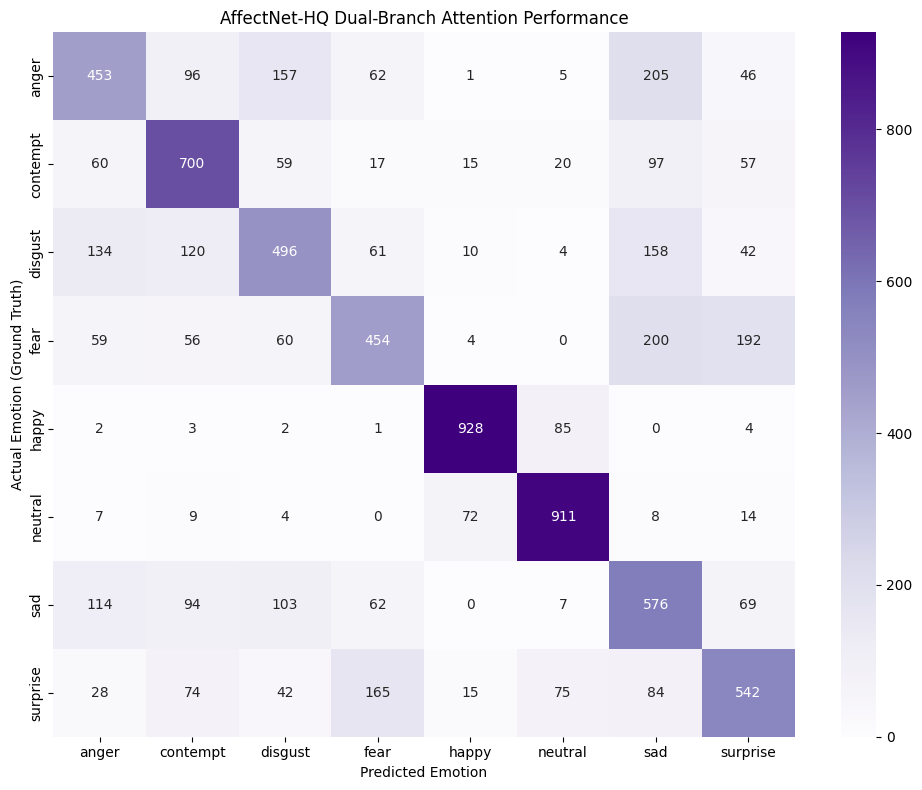

Classification Report
              precision    recall  f1-score   support

       anger       0.53      0.44      0.48      1025
    contempt       0.61      0.68      0.64      1025
     disgust       0.54      0.48      0.51      1025
        fear       0.55      0.44      0.49      1025
       happy       0.89      0.91      0.90      1025
     neutral       0.82      0.89      0.85      1025
         sad       0.43      0.56      0.49      1025
    surprise       0.56      0.53      0.54      1025

    accuracy                           0.62      8200
   macro avg       0.62      0.62      0.61      8200
weighted avg       0.62      0.62      0.61      8200



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Running inference on TEST set...")

test_ds_eval = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get True Labels
y_true = np.concatenate([y for x, y in test_ds_eval], axis=0)
y_true = np.argmax(y_true, axis=1)

# Get Predictions
y_pred_probs = model.predict(test_ds_eval)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('AffectNet-HQ Dual-Branch Attention Performance')
plt.ylabel('Actual Emotion (Ground Truth)')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.show()

print("Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))